In [1]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, GridSearchCV)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, roc_curve)

plt.rcParams.update({"font.family": "serif", "font.serif": ["Times New Roman", "DejaVu Serif"],
                     "font.size": 12, "axes.titleweight": "bold",
                     "savefig.dpi": 300, "savefig.bbox": "tight"})
BLUE, ORANGE = "#1F4E79", "#C55A11"
RANDOM_STATE = 42
os.makedirs("figures", exist_ok=True)
os.makedirs("tables", exist_ok=True)
print("Environment ready. scikit-learn SVC (RBF kernel) will be used throughout.")

Environment ready. scikit-learn SVC (RBF kernel) will be used throughout.


In [2]:
df = pd.read_csv("weatherAUS.csv")
print("Records:", df.shape[0], "| Attributes:", df.shape[1])
df.head()

Records: 145460 | Attributes: 23


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [3]:
df.info()
print("\nTarget distribution:")
print(df["RainTomorrow"].value_counts(dropna=False))
print("\nTop missing-value features (%):")
print(df.isna().mean().mul(100).round(1).sort_values(ascending=False).head(12))
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


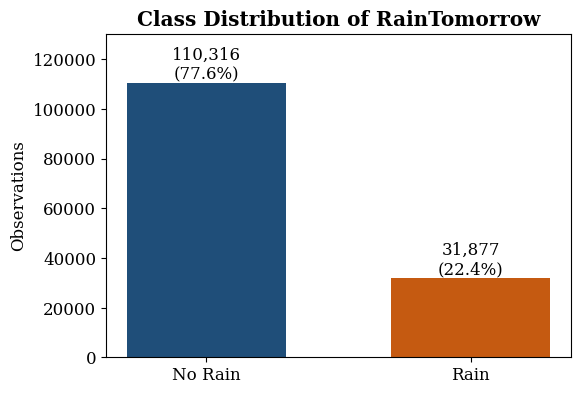

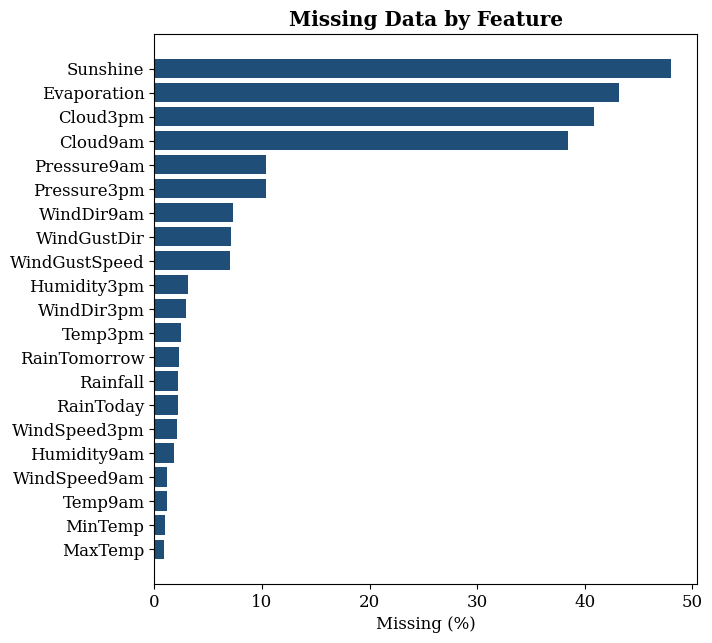

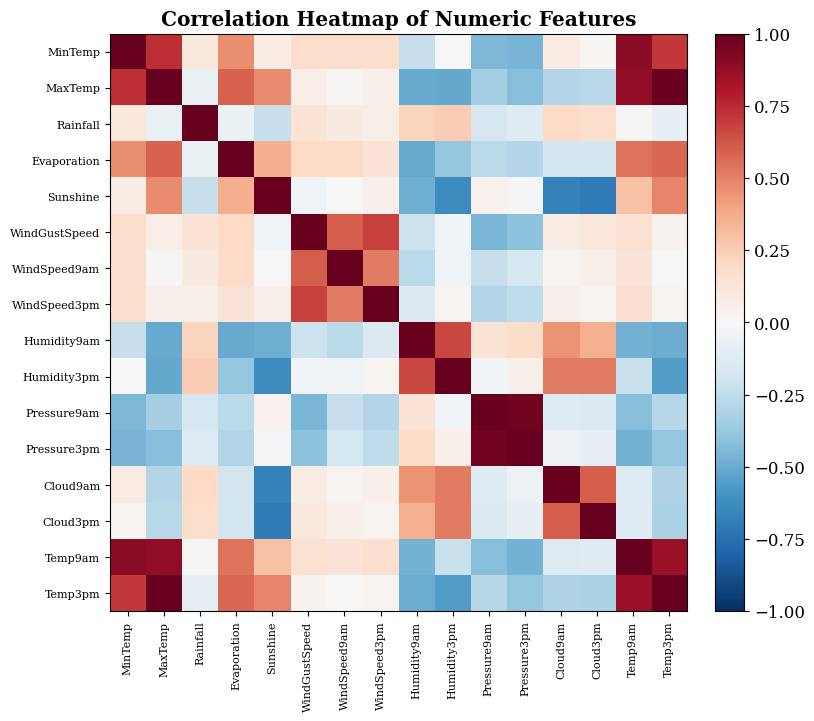

In [4]:
# Figure 3.3 / 4.1: class distribution
counts = df["RainTomorrow"].map({"No": 0, "Yes": 1}).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6, 4.2))
bars = ax.bar(["No Rain", "Rain"], counts.values, color=[BLUE, ORANGE], width=0.6)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x()+b.get_width()/2, v, f"{v:,}\n({v/counts.sum()*100:.1f}%)", ha="center", va="bottom")
ax.set_title("Class Distribution of RainTomorrow"); ax.set_ylabel("Observations")
ax.set_ylim(0, counts.max()*1.18)
plt.savefig("figures/fig3_3_class_distribution.png"); plt.show()

# Figure 3.2: missing values
miss = df.isna().mean().mul(100).sort_values(ascending=False); miss = miss[miss > 0]
fig, ax = plt.subplots(figsize=(7, max(3.5, 0.34*len(miss))))
ax.barh(miss.index[::-1], miss.values[::-1], color=BLUE)
ax.set_xlabel("Missing (%)"); ax.set_title("Missing Data by Feature")
plt.savefig("figures/fig3_5_missing_values.png"); plt.show()

# Figure 3.4: correlation heatmap
corr = df.select_dtypes(include="number").corr()
fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=8); ax.set_yticklabels(corr.columns, fontsize=8)
ax.set_title("Correlation Heatmap of Numeric Features")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.savefig("figures/fig3_4_correlation_heatmap.png"); plt.show()

Encoded features: 115
Train class balance: 77.6% No Rain / 22.4% Rain


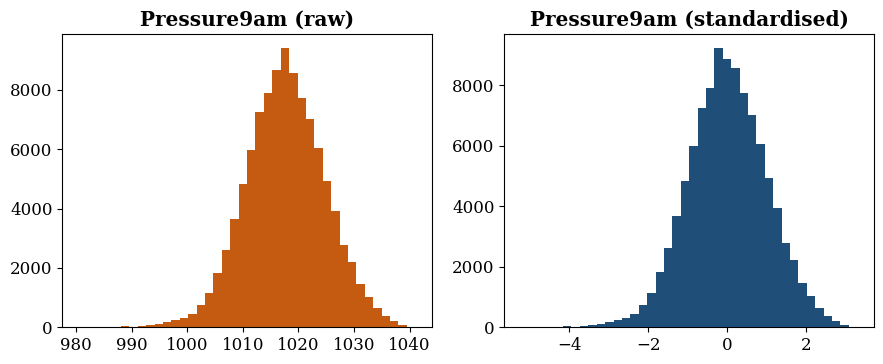

In [5]:
# --- Cleaning (documents §3.4): remove leakage attribute, encode target, engineer Month
for leak in ["RISK_MM", "Risk_MM", "risk_mm"]:
    if leak in df.columns:
        df = df.drop(columns=[leak]); print("Dropped leakage column:", leak)
df = df.dropna(subset=["RainTomorrow"]).reset_index(drop=True)
for c in ["RainTomorrow", "RainToday"]:
    df[c] = df[c].map({"Yes": 1, "No": 0}).astype(float)
df["Month"] = pd.to_datetime(df["Date"], errors="coerce").dt.month
df = df.drop(columns=["Date"])

# --- Split BEFORE fitting any transformer (leakage-free design, §3.1)
y = df["RainTomorrow"].astype(int).values
X = df.drop(columns=["RainTomorrow"])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

# --- Impute + one-hot encode + standardise, fit on TRAIN only (§3.4–3.5)
num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), num_cols),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])
Xtr = preprocessor.fit_transform(X_train); Xte = preprocessor.transform(X_test)
Xtr = Xtr.toarray() if hasattr(Xtr, "toarray") else Xtr
Xte = Xte.toarray() if hasattr(Xte, "toarray") else Xte
feat_names = list(preprocessor.get_feature_names_out())
n_total = Xtr.shape[1]
print("Encoded features:", n_total)
print(f"Train class balance: {100-y_train.mean()*100:.1f}% No Rain / {y_train.mean()*100:.1f}% Rain")

# Figure 3.5: effect of standardisation on a representative feature
feat = "Pressure9am"
raw = X_train[feat].dropna().values
scaled = (raw - np.median(raw)) / raw.std()
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
axes[0].hist(raw, bins=40, color=ORANGE); axes[0].set_title(f"{feat} (raw)")
axes[1].hist(scaled, bins=40, color=BLUE); axes[1].set_title(f"{feat} (standardised)")
plt.tight_layout(); plt.savefig("figures/fig3_5_scaling.png"); plt.show()

In [6]:
def evaluate_model(model, X_fit, y_fit, X_eval, y_eval, label):
    """Trains a model and computes every metric reported in Chapter 4.
    Definitions (from the confusion matrix TP/TN/FP/FN):
      Accuracy    = (TP+TN)/(TP+TN+FP+FN)          -- Eq 3.4
      Precision   = TP/(TP+FP)                     -- Eq 3.5
      Recall      = TP/(TP+FN)   (sensitivity)     -- Eq 3.6
      Specificity = TN/(TN+FP)                     -- true-negative rate
      F1          = 2PR/(P+R)                      -- Eq 3.7
      AUC         = area under the ROC curve (threshold-independent)
      train_time  = wall-clock seconds to fit the model
      pred_time   = wall-clock seconds to predict the full test set
    """
    t0 = time.time(); model.fit(X_fit, y_fit); train_time = time.time() - t0
    t0 = time.time(); pred = model.predict(X_eval); pred_time = time.time() - t0
    score = model.decision_function(X_eval)
    tn, fp, fn, tp = confusion_matrix(y_eval, pred).ravel()
    return {"model": label, "n_features": X_fit.shape[1],
            "accuracy": accuracy_score(y_eval, pred),
            "precision": precision_score(y_eval, pred, zero_division=0),
            "recall": recall_score(y_eval, pred, zero_division=0),
            "specificity": tn / (tn + fp),
            "f1": f1_score(y_eval, pred, zero_division=0),
            "auc": roc_auc_score(y_eval, score),
            "train_time_s": round(train_time, 2),
            "pred_time_s": round(pred_time, 3),
            "_pred": pred, "_score": score}

In [7]:
FINAL_SAMPLE = 20000   # stratified sample for tractable RBF-SVM training (report in §3.7)

def sample_train(Xa, ya):
    if FINAL_SAMPLE and Xa.shape[0] > FINAL_SAMPLE:
        idx, _ = train_test_split(np.arange(Xa.shape[0]), train_size=FINAL_SAMPLE,
                                  stratify=ya, random_state=RANDOM_STATE)
        return Xa[idx], ya[idx]
    return Xa, ya

def tuned_svm(Xa, ya, seed=0):
    """Grid search over C and gamma (roc_auc criterion), returns best estimator + tuning time."""
    skf = StratifiedKFold(3, shuffle=True, random_state=seed)
    gs = GridSearchCV(SVC(kernel="rbf", class_weight="balanced", random_state=seed),
                      {"C": (0.1, 1.0, 10.0), "gamma": ("scale", 0.1, 1.0)},
                      scoring="roc_auc", cv=skf, n_jobs=-1)
    t0 = time.time(); gs.fit(Xa, ya); tune_time = time.time() - t0
    return gs.best_estimator_, gs.best_params_, round(tune_time, 2)

Xa, ya = sample_train(Xtr, y_train)
best_base, base_params, base_tune_t = tuned_svm(Xa, ya)
base = evaluate_model(SVC(kernel="rbf", class_weight="balanced", random_state=RANDOM_STATE,
                          **{k: v for k, v in base_params.items()}),
                      Xa, ya, Xte, y_test, "Baseline (all features)")
base["tuning_time_s"] = base_tune_t
print("BASELINE:", {k: (round(v,3) if isinstance(v,(int,float)) else v)
                    for k, v in base.items() if not k.startswith("_")})

BASELINE: {'model': 'Baseline (all features)', 'n_features': 115, 'accuracy': 0.814, 'precision': 0.562, 'recall': 0.776, 'specificity': np.float64(0.825), 'f1': 0.652, 'auc': np.float64(0.882), 'train_time_s': 58.33, 'pred_time_s': 49.935, 'tuning_time_s': 1485.19}


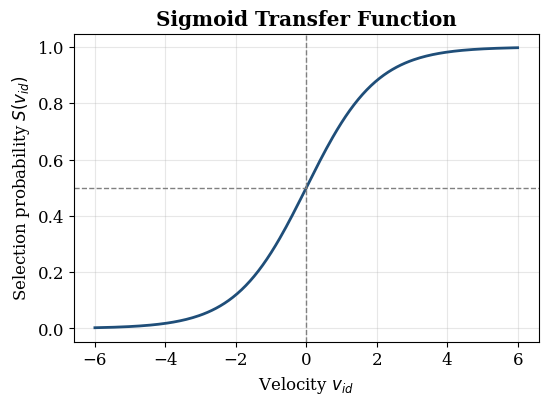

  seed 42 | iter 01/30 | w=0.90 | fit 0.2298 | feats 50
  seed 42 | iter 02/30 | w=0.88 | fit 0.2298 | feats 50
  seed 42 | iter 03/30 | w=0.87 | fit 0.2277 | feats 53
  seed 42 | iter 04/30 | w=0.85 | fit 0.2240 | feats 48
  seed 42 | iter 05/30 | w=0.83 | fit 0.2240 | feats 48
  seed 42 | iter 06/30 | w=0.81 | fit 0.2240 | feats 48
  seed 42 | iter 07/30 | w=0.80 | fit 0.2240 | feats 48
  seed 42 | iter 08/30 | w=0.78 | fit 0.2203 | feats 47
  seed 42 | iter 09/30 | w=0.76 | fit 0.2203 | feats 47
  seed 42 | iter 10/30 | w=0.74 | fit 0.2203 | feats 47
  seed 42 | iter 11/30 | w=0.73 | fit 0.2203 | feats 47
  seed 42 | iter 12/30 | w=0.71 | fit 0.2203 | feats 47
  seed 42 | iter 13/30 | w=0.69 | fit 0.2203 | feats 47
  seed 42 | iter 14/30 | w=0.68 | fit 0.2203 | feats 47
  seed 42 | iter 15/30 | w=0.66 | fit 0.2203 | feats 47
  seed 42 | iter 16/30 | w=0.64 | fit 0.2203 | feats 47
  seed 42 | iter 17/30 | w=0.62 | fit 0.2171 | feats 47
  seed 42 | iter 18/30 | w=0.61 | fit 0.2171 | f

In [8]:
# --- PSO parameters (Table 3.2) ---
FIT_SUBSAMPLE = 6000; FIT_CV = 3; ALPHA = 0.90
N_PARTICLES, N_ITER = 20, 30
W_MAX, W_MIN, C1, C2 = 0.9, 0.4, 1.5, 1.5
N_RUNS = 3

def fitness(mask, Xf, yf, seed=0):
    """Eq 3.3: alpha*(1-accuracy) + (1-alpha)*(k/n); accuracy by stratified 3-fold CV."""
    if mask.sum() == 0: return 1.0
    cols = np.where(mask == 1)[0]
    skf = StratifiedKFold(n_splits=FIT_CV, shuffle=True, random_state=seed)
    acc = cross_val_score(SVC(kernel="rbf", class_weight="balanced", random_state=seed),
                          Xf[:, cols], yf, cv=skf, scoring="accuracy", n_jobs=-1).mean()
    return ALPHA*(1-acc) + (1-ALPHA)*(mask.sum()/mask.size)

def sigmoid(v): return 1/(1+np.exp(-np.clip(v, -10, 10)))   # Eq 2.3

# Figure 3.8: the sigmoid transfer function itself
v = np.linspace(-6, 6, 200)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(v, sigmoid(v), color=BLUE, lw=2)
ax.axhline(0.5, ls="--", c="grey", lw=1); ax.axvline(0, ls="--", c="grey", lw=1)
ax.set_xlabel("Velocity $v_{id}$"); ax.set_ylabel("Selection probability $S(v_{id})$")
ax.set_title("Sigmoid Transfer Function"); ax.grid(alpha=0.3)
plt.savefig("figures/fig3_8_sigmoid.png"); plt.show()

def binary_pso(Xf, yf, seed=0):
    rng = np.random.default_rng(seed); n = Xf.shape[1]
    Xp = rng.integers(0, 2, (N_PARTICLES, n)); V = rng.uniform(-1, 1, (N_PARTICLES, n))
    pbest = Xp.copy()
    pf = np.array([fitness(Xp[i], Xf, yf, seed) for i in range(N_PARTICLES)])
    g = int(np.argmin(pf)); gbest, gf = pbest[g].copy(), pf[g]; hist = [gf]
    for it in range(N_ITER):
        w = W_MAX - (W_MAX-W_MIN)*it/max(1, N_ITER-1)          # Eq 3.2 (decaying inertia)
        V = w*V + C1*rng.random((N_PARTICLES, n))*(pbest-Xp) \
                + C2*rng.random((N_PARTICLES, n))*(gbest-Xp)   # Eq 3.1
        Xp = (rng.random((N_PARTICLES, n)) < sigmoid(V)).astype(int)
        for i in range(N_PARTICLES):
            f = fitness(Xp[i], Xf, yf, seed)
            if f < pf[i]: pf[i], pbest[i] = f, Xp[i].copy()
        g = int(np.argmin(pf))
        if pf[g] < gf: gf, gbest = pf[g], pbest[g].copy()
        hist.append(gf)
        print(f"  seed {seed} | iter {it+1:02d}/{N_ITER} | w={w:.2f} | fit {gf:.4f} | feats {int(gbest.sum())}")
    return gbest, gf, hist

# Stratified subsample for the wrapper loop (§3.8)
sub, _ = train_test_split(np.arange(Xtr.shape[0]), train_size=min(FIT_SUBSAMPLE, Xtr.shape[0]),
                          stratify=y_train, random_state=RANDOM_STATE)
Xf, yf = Xtr[sub], y_train[sub]

masks, fits, histories, search_times = [], [], [], []
for r in range(N_RUNS):
    t0 = time.time()
    gbest, gf, hist = binary_pso(Xf, yf, seed=RANDOM_STATE + r)
    search_times.append(round(time.time() - t0, 1))
    masks.append(gbest); fits.append(gf); histories.append(hist)
    print(f"-> run {r+1}: {int(gbest.sum())} features | fitness {gf:.4f} | search time {search_times[-1]}s")

counts = [int(m.sum()) for m in masks]
best = int(np.argmin(fits)); mask = masks[best]; cols = np.where(mask == 1)[0]
selected_features = [feat_names[i] for i in cols]

# Table 4.3 — per-run record (REAL numbers, saved directly)
runs_df = pd.DataFrame({"run": range(1, N_RUNS+1), "n_features": counts,
                        "fitness": [round(f, 4) for f in fits],
                        "search_time_s": search_times})
runs_df.to_csv("tables/table4_3_pso_runs.csv", index=False)
print(runs_df.to_string(index=False))
print(f"\nMean features: {np.mean(counts):.1f} ± {np.std(counts):.1f} | "
      f"best {int(mask.sum())}/{n_total} ({(1-mask.sum()/n_total)*100:.1f}% reduction) | "
      f"total PSO time: {sum(search_times):.0f}s")

In [9]:
Xa_s, ya_s = sample_train(Xtr[:, cols], y_train)
best_sel, sel_params, sel_tune_t = tuned_svm(Xa_s, ya_s)
sel = evaluate_model(SVC(kernel="rbf", class_weight="balanced", random_state=RANDOM_STATE,
                         **{k: v for k, v in sel_params.items()}),
                     Xa_s, ya_s, Xte[:, cols], y_test, "PSO + SVM")
sel["tuning_time_s"] = sel_tune_t
print("PSO+SVM:", {k: (round(v,3) if isinstance(v,(int,float)) else v)
                   for k, v in sel.items() if not k.startswith("_")})
print("\n", classification_report(y_test, sel["_pred"], target_names=["No Rain", "Rain"]))

PSO+SVM: {'model': 'PSO + SVM', 'n_features': 47, 'accuracy': 0.809, 'precision': 0.553, 'recall': 0.765, 'specificity': np.float64(0.821), 'f1': 0.642, 'auc': np.float64(0.873), 'train_time_s': 31.15, 'pred_time_s': 31.094, 'tuning_time_s': 705.77}

               precision    recall  f1-score   support

     No Rain       0.92      0.82      0.87     22064
        Rain       0.55      0.77      0.64      6375

    accuracy                           0.81     28439
   macro avg       0.74      0.79      0.76     28439
weighted avg       0.84      0.81      0.82     28439



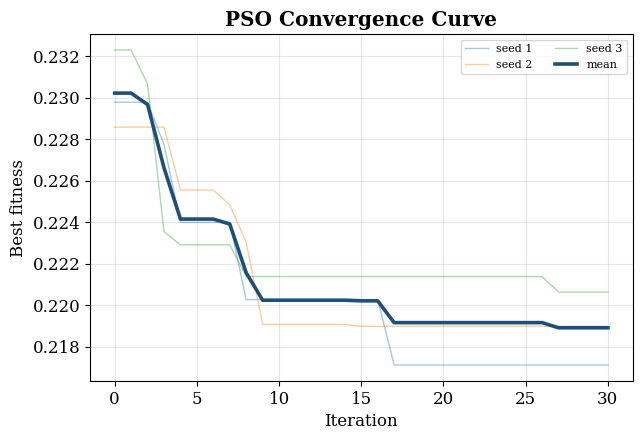

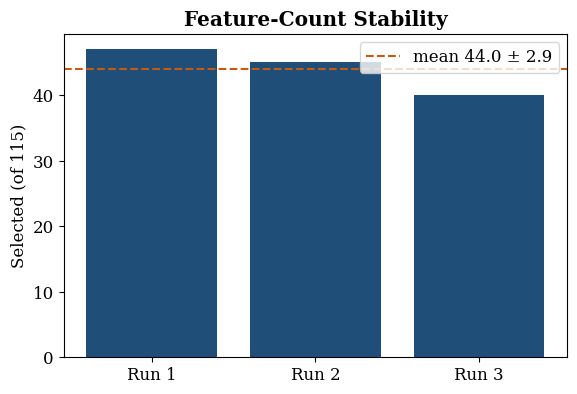

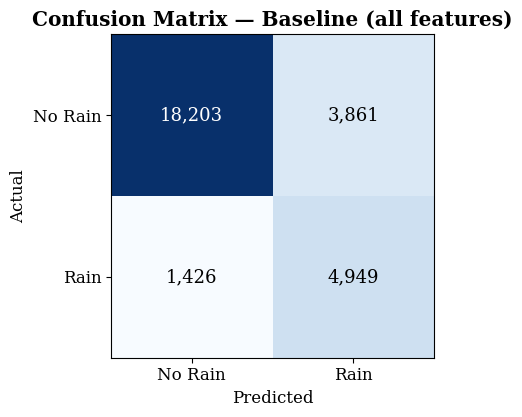

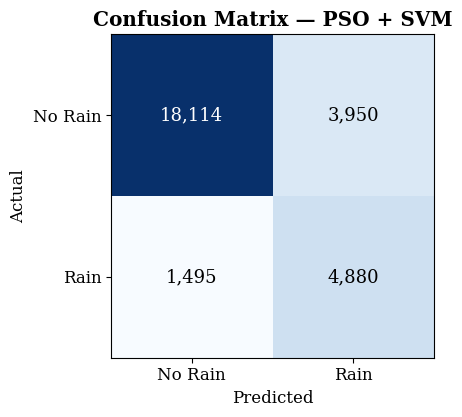

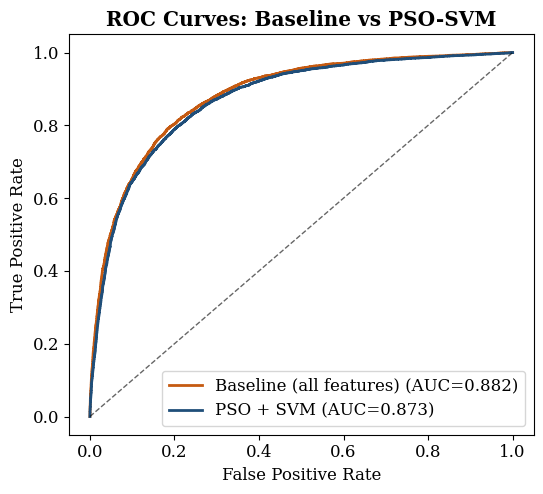

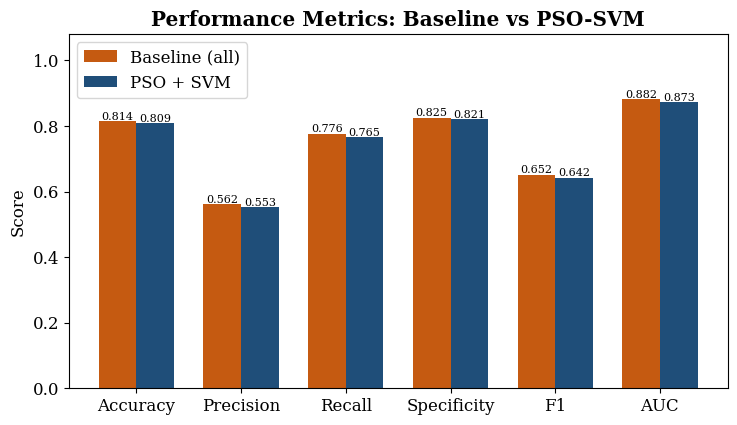

                  model  n_features  accuracy  precision   recall  specificity       f1      auc  tuning_time_s  train_time_s  pred_time_s  feature_reduction_%
Baseline (all features)         115  0.814093   0.561748 0.776314     0.825009 0.651827 0.881583        1485.19         58.33       49.935                  0.0
              PSO + SVM          47  0.808538   0.552661 0.765490     0.820975 0.641894 0.872936         705.77         31.15       31.094                 59.1


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
# Fig 4.3: convergence
fig, ax = plt.subplots(figsize=(7, 4.5))
for i, h in enumerate(histories): ax.plot(h, alpha=0.4, lw=1, label=f"seed {i+1}")
ax.plot(np.array(histories).mean(0), color=BLUE, lw=2.6, label="mean")
ax.set_xlabel("Iteration"); ax.set_ylabel("Best fitness"); ax.set_title("PSO Convergence Curve")
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)
plt.savefig("figures/fig4_1_pso_convergence.png"); plt.show()

# Fig 4.4: feature-count stability
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.bar([f"Run {i+1}" for i in range(len(counts))], counts, color=BLUE)
ax.axhline(np.mean(counts), color=ORANGE, ls="--",
           label=f"mean {np.mean(counts):.1f} ± {np.std(counts):.1f}")
ax.set_ylabel(f"Selected (of {n_total})"); ax.set_title("Feature-Count Stability"); ax.legend()
plt.savefig("figures/fig4_2_feature_stability.png"); plt.show()

# Figs 4.2 & 4.5: confusion matrices
for res, tag in [(base, "baseline"), (sel, "pso")]:
    cm = confusion_matrix(y_test, res["_pred"])
    fig, ax = plt.subplots(figsize=(4.6, 4.2)); ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["No Rain","Rain"]); ax.set_yticklabels(["No Rain","Rain"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix — {res['model']}")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                    color="white" if cm[i,j] > cm.max()/2 else "black", fontsize=13)
    plt.savefig(f"figures/fig4_3_confusion_{tag}.png"); plt.show()

# Fig 4.7: ROC curves
fig, ax = plt.subplots(figsize=(6, 5.2))
for res, color in [(base, ORANGE), (sel, BLUE)]:
    fpr, tpr, _ = roc_curve(y_test, res["_score"])
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{res['model']} (AUC={res['auc']:.3f})")
ax.plot([0,1],[0,1],"k--",lw=1,alpha=0.6)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves: Baseline vs PSO-SVM"); ax.legend(loc="lower right")
plt.savefig("figures/fig4_5_roc_curves.png"); plt.show()

# Fig 4.6: metrics comparison (now includes specificity)
metrics = ["accuracy","precision","recall","specificity","f1","auc"]
labels  = ["Accuracy","Precision","Recall","Specificity","F1","AUC"]
x = np.arange(len(metrics)); wd = 0.36
fig, ax = plt.subplots(figsize=(8.5, 4.6))
b1 = ax.bar(x-wd/2, [base[m] for m in metrics], wd, label="Baseline (all)", color=ORANGE)
b2 = ax.bar(x+wd/2, [sel[m] for m in metrics], wd, label="PSO + SVM", color=BLUE)
for bars in (b1, b2):
    for b in bars: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                           f"{b.get_height():.3f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylim(0, 1.08)
ax.set_ylabel("Score"); ax.set_title("Performance Metrics: Baseline vs PSO-SVM"); ax.legend()
plt.savefig("figures/fig4_6_metrics_comparison.png"); plt.show()

# Tables 4.2 / 4.4 / 4.5 — full comparison with all metrics and times
results = pd.DataFrame([{k: v for k, v in base.items() if not k.startswith("_")},
                        {k: v for k, v in sel.items() if not k.startswith("_")}])
results["feature_reduction_%"] = [0, round((1 - sel["n_features"]/base["n_features"])*100, 1)]
results.to_csv("tables/table4_5_comparison.csv", index=False)
pd.DataFrame({"selected_feature": selected_features}).to_csv("tables/table4_2_selected_features.csv", index=False)
print(results[["model","n_features","accuracy","precision","recall","specificity",
               "f1","auc","tuning_time_s","train_time_s","pred_time_s","feature_reduction_%"]].to_string(index=False))

# Zip and download everything
import shutil
shutil.make_archive("fyp_figures", "zip", ".", "figures")
shutil.make_archive("fyp_tables", "zip", ".", "tables")
from google.colab import files
files.download("fyp_figures.zip"); files.download("fyp_tables.zip")

In [11]:
import joblib, os

os.makedirs("models", exist_ok=True)

# Trained models (must have probability=True for predict_proba on the Streamlit side)
best_base_proba = SVC(kernel="rbf", class_weight="balanced", probability=True,
                      random_state=RANDOM_STATE, **base_params)
best_base_proba.fit(Xa, ya)   # Xa, ya = the sampled training data used in Cell 7

best_sel_proba = SVC(kernel="rbf", class_weight="balanced", probability=True,
                     random_state=RANDOM_STATE, **sel_params)
best_sel_proba.fit(Xa_s, ya_s)   # Xa_s, ya_s = the sampled training data used in Cell 9

joblib.dump(best_base_proba, "models/svm_baseline.joblib")
joblib.dump(best_sel_proba, "models/svm_pso_selected.joblib")
joblib.dump(preprocessor, "models/preprocessor.joblib")
joblib.dump(cols, "models/selected_feature_indices.joblib")
joblib.dump(feat_names, "models/feature_names.joblib")

# Raw input schema — lets Streamlit build the form without hardcoding options
num_cols_raw = X_train.select_dtypes(include="number").columns.tolist()
cat_cols_raw = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
schema = {
    "numeric_cols": num_cols_raw,
    "categorical_cols": cat_cols_raw,
    "categorical_options": {c: sorted(X_train[c].dropna().unique().tolist()) for c in cat_cols_raw},
    "numeric_ranges": {c: (float(X_train[c].min()), float(X_train[c].max()), float(X_train[c].median()))
                       for c in num_cols_raw},
}
joblib.dump(schema, "models/input_schema.joblib")

print("Saved:", sorted(os.listdir("models")))

import shutil
shutil.make_archive("fyp_models", "zip", ".", "models")
from google.colab import files
files.download("fyp_models.zip")

Saved: ['feature_names.joblib', 'input_schema.joblib', 'preprocessor.joblib', 'selected_feature_indices.joblib', 'svm_baseline.joblib', 'svm_pso_selected.joblib']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>